# Chapter 1: Introduction to Agentic AI in Cancer Research

## Concept Notebook

This notebook turns the chapter concepts into small, runnable examples.

You will:

- compare major AI paradigms that led to agentic systems
- visualize why oncology tasks benefit from planning, retrieval, and tool use
- map common cancer research tasks to core agent components
- draft a simple human-supervised agent plan for a biomedical question

This notebook uses only local, synthetic examples so it runs without external APIs or datasets.

---

## Section 1: Setup and Shared Example Data

We will create a few compact tables that represent the ideas from the chapter:
the evolution of AI systems, the importance of agent components, and a simple oncology workflow checklist.

In [1]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ai_evolution = pd.DataFrame(
    [
        {
            "era": "Rule-based systems",
            "primary_value": "Interpretability",
            "main_limit": "Rigid and difficult to scale",
            "adaptability": 1,
            "autonomy": 1,
            "tool_integration": 1,
        },
        {
            "era": "Statistical ML",
            "primary_value": "Pattern detection",
            "main_limit": "Feature engineering burden",
            "adaptability": 2,
            "autonomy": 1,
            "tool_integration": 1,
        },
        {
            "era": "Deep learning",
            "primary_value": "Representation learning",
            "main_limit": "Task-specific deployment",
            "adaptability": 3,
            "autonomy": 2,
            "tool_integration": 2,
        },
        {
            "era": "Foundation models",
            "primary_value": "General language reasoning",
            "main_limit": "Knowledge staleness without grounding",
            "adaptability": 4,
            "autonomy": 3,
            "tool_integration": 3,
        },
        {
            "era": "Agentic AI",
            "primary_value": "Goal-directed orchestration",
            "main_limit": "Reliability and governance complexity",
            "adaptability": 5,
            "autonomy": 4,
            "tool_integration": 5,
        },
    ]
)

task_component_matrix = pd.DataFrame(
    {
        "Planning": [2, 4, 5, 4, 4],
        "Retrieval": [5, 4, 3, 4, 5],
        "Tool Use": [1, 4, 5, 3, 4],
        "Memory": [2, 3, 4, 4, 5],
        "Reflection": [3, 4, 4, 3, 5],
        "Human Oversight": [4, 5, 5, 5, 5],
    },
    index=[
        "Literature triage",
        "Variant interpretation",
        "Single-cell workflow orchestration",
        "Clinical trial matching",
        "Translational evidence report",
    ],
)

workflow_checklist = pd.DataFrame(
    [
        {
            "workflow_stage": "Question framing",
            "agent_role": "Clarify objective and required evidence",
            "human_role": "Approve scope and success criteria",
        },
        {
            "workflow_stage": "Evidence collection",
            "agent_role": "Retrieve papers, databases, and metadata",
            "human_role": "Review relevance and source quality",
        },
        {
            "workflow_stage": "Analysis orchestration",
            "agent_role": "Sequence tools and record intermediate results",
            "human_role": "Validate assumptions and parameters",
        },
        {
            "workflow_stage": "Draft synthesis",
            "agent_role": "Prepare cited summary with open questions",
            "human_role": "Edit interpretation and decide next action",
        },
    ]
)

print("Loaded chapter example tables.")
display(ai_evolution)

Loaded chapter example tables.


,era,primary_value,main_limit,adaptability,autonomy,tool_integration
0,Rule-based systems,Interpretability,Rigid and difficult to scale,1,1,1
1,Statistical ML,Pattern detection,Feature engineering burden,2,1,1
2,Deep learning,Representation learning,Task-specific deployment,3,2,2
3,Foundation models,General language reasoning,Knowledge staleness without grounding,4,3,3
4,Agentic AI,Goal-directed orchestration,Reliability and governance complexity,5,4,5


## Section 2: Inspect the Evolution of AI Systems

The table below summarizes the progression from rule-based systems to agentic AI.
Notice that the largest jump is not only model quality, but the addition of dynamic planning and tool orchestration.

In [3]:
ai_evolution = ai_evolution.assign(
    overall_agentic_capacity=ai_evolution[["adaptability", "autonomy", "tool_integration"]].sum(axis=1)
 )

summary_columns = [
    "era",
    "primary_value",
    "main_limit",
    "adaptability",
    "autonomy",
    "tool_integration",
    "overall_agentic_capacity",
]

display(ai_evolution[summary_columns].sort_values("overall_agentic_capacity"))

,era,primary_value,main_limit,adaptability,autonomy,tool_integration,overall_agentic_capacity
0,Rule-based systems,Interpretability,Rigid and difficult to scale,1,1,1,3
1,Statistical ML,Pattern detection,Feature engineering burden,2,1,1,4
2,Deep learning,Representation learning,Task-specific deployment,3,2,2,7
3,Foundation models,General language reasoning,Knowledge staleness without grounding,4,3,3,10
4,Agentic AI,Goal-directed orchestration,Reliability and governance complexity,5,4,5,14


## Section 3: Graphical Summary of the Shift to Agentic AI

These charts visualize why agentic systems matter in cancer research.
They are more adaptable than earlier paradigms and are much better suited to multi-step, tool-heavy workflows.

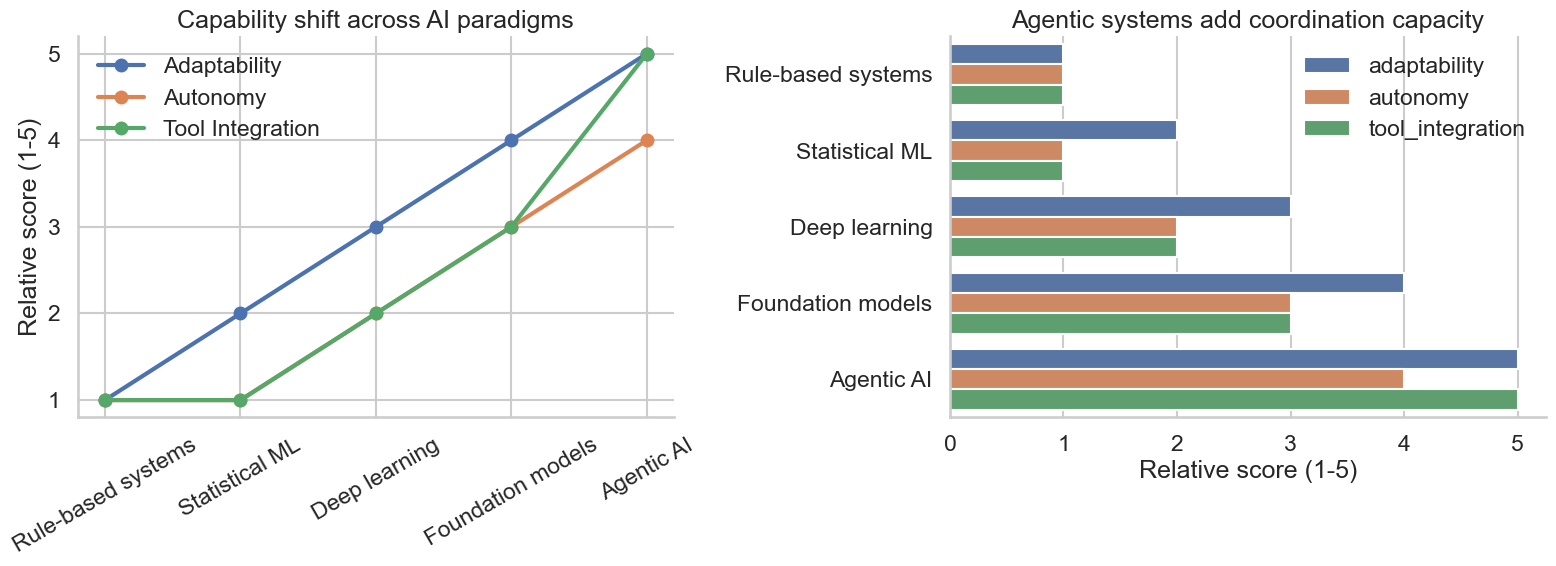

In [4]:
score_columns = ["adaptability", "autonomy", "tool_integration"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for column in score_columns:
    axes[0].plot(
        ai_evolution["era"],
        ai_evolution[column],
        marker="o",
        linewidth=3,
        label=column.replace("_", " ").title(),
    )

axes[0].set_title("Capability shift across AI paradigms")
axes[0].set_ylabel("Relative score (1-5)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(frameon=False)

melted_scores = ai_evolution.melt(
    id_vars="era",
    value_vars=score_columns,
    var_name="capability",
    value_name="score",
)

sns.barplot(
    data=melted_scores,
    x="score",
    y="era",
    hue="capability",
    orient="h",
    ax=axes[1],
)
axes[1].set_title("Agentic systems add coordination capacity")
axes[1].set_xlabel("Relative score (1-5)")
axes[1].set_ylabel("")
axes[1].legend(title="", frameon=False)

plt.tight_layout()
plt.show()

## Section 4: Map Oncology Tasks to Agent Components

Not every cancer research problem needs the same kind of agent.
The table below assigns rough importance scores from 1 to 5 for each core component described in the chapter, which helps decide where deeper orchestration is worth the added complexity.

In [5]:
display(task_component_matrix)

coordination_score = task_component_matrix.sum(axis=1).sort_values(ascending=False)

print("Tasks with the highest estimated coordination burden:")
display(coordination_score.to_frame(name="coordination_score"))

print("\nHuman oversight stays high across every task because biomedical outputs need expert review.")

,Planning,Retrieval,Tool Use,Memory,Reflection,Human Oversight
Literature triage,2,5,1,2,3,4
Variant interpretation,4,4,4,3,4,5
Single-cell workflow orchestration,5,3,5,4,4,5
Clinical trial matching,4,4,3,4,3,5
Translational evidence report,4,5,4,5,5,5


Tasks with the highest estimated coordination burden:


,coordination_score
Translational evidence report,28
Single-cell workflow orchestration,26
Variant interpretation,24
Clinical trial matching,23
Literature triage,17



Human oversight stays high across every task because biomedical outputs need expert review.


## Section 5: Graphical Summary of Agent Design Pressure

The heatmap emphasizes where planning, retrieval, memory, and human oversight become critical.
This is a useful way to decide whether a research workflow needs a simple assistant or a more structured agent architecture.

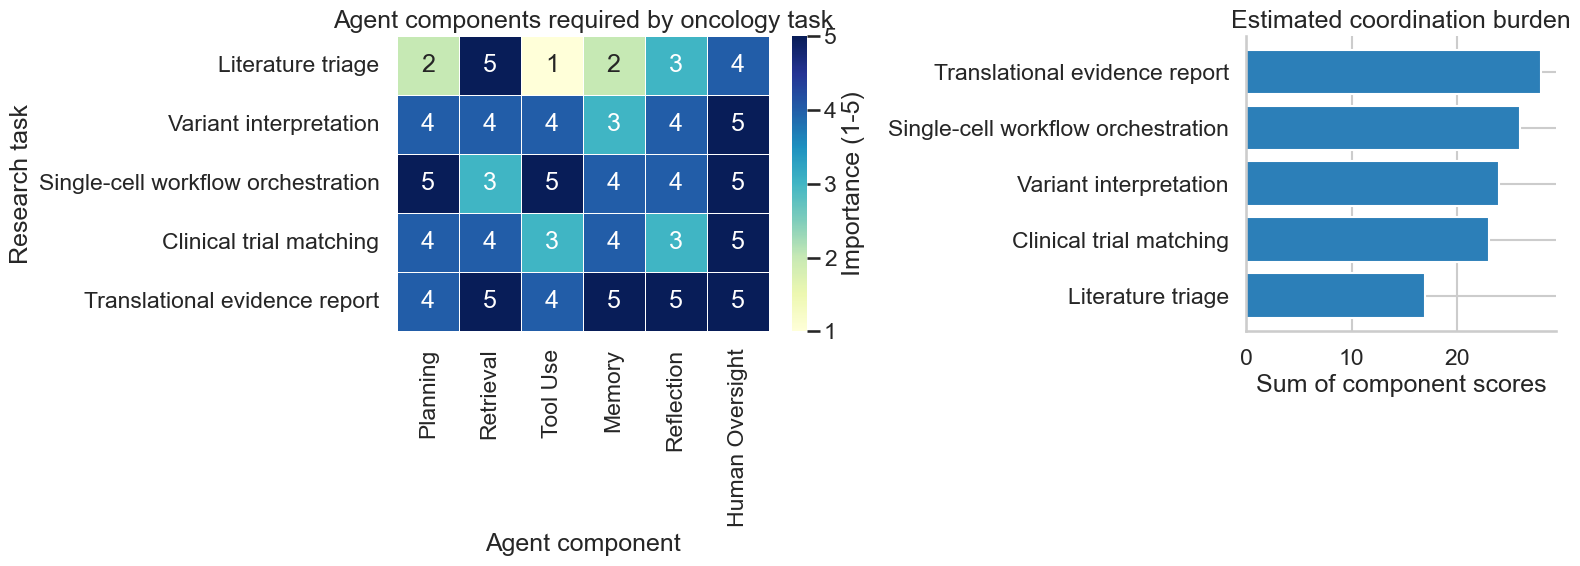

In [6]:
coordination_score = task_component_matrix.sum(axis=1).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.5, 1]})

sns.heatmap(
    task_component_matrix,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5,
    vmin=1,
    vmax=5,
    cbar_kws={"label": "Importance (1-5)"},
    ax=axes[0],
)
axes[0].set_title("Agent components required by oncology task")
axes[0].set_xlabel("Agent component")
axes[0].set_ylabel("Research task")

axes[1].barh(coordination_score.index, coordination_score.values, color="#2c7fb8")
axes[1].set_title("Estimated coordination burden")
axes[1].set_xlabel("Sum of component scores")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Section 6: Evidence Grounding Mini Example

This section simulates a small retrieval-and-synthesis step.
The point is not to do real PubMed search yet, but to show how an agent should compare supporting and conflicting evidence before drafting a claim.

In [8]:
evidence_records = pd.DataFrame(
    [
        {
            "source": "Study A",
            "finding": "PD-L1 expression correlated with response in one melanoma cohort",
            "stance": "supporting",
            "confidence": 0.76,
        },
        {
            "source": "Study B",
            "finding": "Association weakened after controlling for tumor mutational burden",
            "stance": "mixed",
            "confidence": 0.62,
        },
        {
            "source": "Study C",
            "finding": "No consistent association across a small validation cohort",
            "stance": "conflicting",
            "confidence": 0.58,
        },
    ]
)

stance_weight = {"supporting": 1.0, "mixed": 0.25, "conflicting": -0.75}
evidence_records["weighted_signal"] = evidence_records.apply(
    lambda row: row["confidence"] * stance_weight[row["stance"]], axis=1
)

draft_claim_strength = evidence_records["weighted_signal"].sum()

if draft_claim_strength > 0.75:
    draft_claim = "Evidence is directionally supportive, but still needs expert review."
elif draft_claim_strength > 0:
    draft_claim = "Evidence is mixed and should be summarized cautiously."
else:
    draft_claim = "Evidence is currently too conflicted for a strong claim."

display(evidence_records)
print(f"Weighted evidence score: {draft_claim_strength:.2f}")
print(f"Draft grounded summary: {draft_claim}")

,source,finding,stance,confidence,weighted_signal
0,Study A,PD-L1 expression correlated with response in o...,supporting,0.76,0.760
1,Study B,Association weakened after controlling for tum...,mixed,0.62,0.155
2,Study C,No consistent association across a small valid...,conflicting,0.58,-0.435


Weighted evidence score: 0.48
Draft grounded summary: Evidence is mixed and should be summarized cautiously.


## Section 7: Real Literature Retrieval (Europe PMC)

This optional step fetches recent abstracts from Europe PMC for a real biomedical query.
If the request cannot be completed (for example, due to network restrictions), the cell falls back to a small local mock dataset so the notebook still runs.

In [10]:
import requests

query = "melanoma immunotherapy resistance biomarker"
epmc_url = "https://www.ebi.ac.uk/europepmc/webservices/rest/search"
params = {
    "query": query,
    "format": "json",
    "resultType": "core",
    "pageSize": 5,
    "sort": "P_PDATE_D desc",
}

def _extract_record(record):
    abstract = record.get("abstractText") or "No abstract available."
    return {
        "id": record.get("id", "NA"),
        "title": record.get("title", "Untitled"),
        "journal": record.get("journalTitle", "Unknown"),
        "year": record.get("pubYear", "Unknown"),
        "abstract_preview": abstract[:240] + ("..." if len(abstract) > 240 else ""),
    }

try:
    response = requests.get(epmc_url, params=params, timeout=12)
    response.raise_for_status()
    payload = response.json()
    records = payload.get("resultList", {}).get("result", [])
    literature_df = pd.DataFrame([_extract_record(r) for r in records])
    retrieval_mode = "live"
except Exception as exc:
    retrieval_mode = f"fallback ({type(exc).__name__})"
    literature_df = pd.DataFrame(
        [
            {
                "id": "MOCK-001",
                "title": "Mock study on melanoma resistance signatures",
                "journal": "Synthetic Oncology Notes",
                "year": "2025",
                "abstract_preview": "Fallback record used when API retrieval is unavailable.",
            },
            {
                "id": "MOCK-002",
                "title": "Mock trial report for immunotherapy biomarker panels",
                "journal": "Synthetic Translational Medicine",
                "year": "2024",
                "abstract_preview": "Use this row only for notebook continuity when offline.",
            },
        ]
    )

print(f"Retrieval mode: {retrieval_mode}")
print(f"Records returned: {len(literature_df)}")
display(literature_df)

Retrieval mode: live
Records returned: 5


,id,title,journal,year,abstract_preview
0,41995675,Oncolytic virus therapy for hepatocellular car...,Unknown,2026,This study aimed to systematically analyze the...
1,41992448,Angiopep-2-decorated bacterial outer membrane ...,Unknown,2026,Glioblastoma (GBM) therapy remains one of the ...
2,41979168,PARP7 inhibition and a STING agonist potentiat...,Unknown,2026,Glioblastoma (GBM) is the most lethal form of ...
3,41963781,Microbiota as a modulator of drug response: ta...,Unknown,2026,"In recent years, accumulating evidence has est..."
4,41956548,Second primary cancers following hematologic m...,Unknown,2026,Second primary cancers (SPCs) pose an increasi...


## Section 8: Guided Exercise

Edit the task description below to match a real question from your domain.
Use the evidence-grounding pattern from the previous sections to decide which sources you would retrieve, what contradictions you would expect, and where human review should happen.

In [11]:
task_description = "Prioritize biomarkers associated with immunotherapy resistance in melanoma"
evidence_sources = [
    "PubMed abstracts",
    "public variant databases",
    "internal differential expression results",
]

review_questions = [
    "Which source is most likely to contain contradictory evidence?",
    "Which step requires the strongest human oversight?",
    "What evidence would make the final report more trustworthy?",
]

def draft_agent_plan(task_description, evidence_sources):
    return pd.DataFrame(
        [
            {
                "step": 1,
                "phase": "Define objective",
                "agent_action": f"Clarify the scope, cohort, and success criteria for: {task_description}.",
            },
            {
                "step": 2,
                "phase": "Retrieve evidence",
                "agent_action": "Collect the most relevant papers, database records, and prior notes.",
            },
            {
                "step": 3,
                "phase": "Run tools",
                "agent_action": "Sequence the required analyses and capture intermediate outputs.",
            },
            {
                "step": 4,
                "phase": "Reflect",
                "agent_action": "Flag missing evidence, contradictions, and low-confidence claims.",
            },
            {
                "step": 5,
                "phase": "Human review",
                "agent_action": "Hand the draft summary and citations to a domain expert for approval.",
            },
        ]
    )

plan = draft_agent_plan(task_description, evidence_sources)

print("Evidence sources for this run:")
for source in evidence_sources:
    print(f"- {source}")

print("\nReview prompts:")
for question in review_questions:
    print(f"- {question}")

display(plan)

Evidence sources for this run:
- PubMed abstracts
- public variant databases
- internal differential expression results

Review prompts:
- Which source is most likely to contain contradictory evidence?
- Which step requires the strongest human oversight?
- What evidence would make the final report more trustworthy?


,step,phase,agent_action
0,1,Define objective,"Clarify the scope, cohort, and success criteri..."
1,2,Retrieve evidence,"Collect the most relevant papers, database rec..."
2,3,Run tools,Sequence the required analyses and capture int...
3,4,Reflect,"Flag missing evidence, contradictions, and low..."
4,5,Human review,Hand the draft summary and citations to a doma...


## Section 9: Key Takeaways

- Agentic AI matters when the problem is multi-step, evidence-heavy, and tool-dependent.
- Oncology workflows often need planning, retrieval, memory, and strong human oversight at the same time.
- Evidence grounding means comparing supporting and conflicting sources before drafting a conclusion.
- Lightweight live retrieval can be integrated safely with fallback behavior for offline environments.
- The right design target is usually a human-supervised research copilot, not an unsupervised decision maker.


## Next Steps

1. Replace the synthetic workflow scores with scores from your own project.
2. Extend the Europe PMC retrieval cell with query templates for your specific cancer subtype.
3. Reuse the planning template for a genomics, pathology, or clinical trial question.

**Last Updated**: May 2026